### 타이타닉 기술통계

STEP#1 - 라이브러리 임포트

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 한글 폰트 관련
from matplotlib import rc
path = "../malgun.ttf"
font_name = fm.FontProperties(fname=path).get_name()
rc('font', family=font_name)
plt.rc('font', family="Malgun Gothic")

python 경고 메시지 무시하는 설정<br>
경고 메시지가 출력되지 않도록 추가함. -> 경고로 인해 코드 실행이 방해 받지 않도록 하려고 함<br>

In [30]:
import warnings
warnings.filterwarnings(action='ignore')

STEP#2 - 훈련데이터( 모형 ) 과 테스트 

In [31]:
df_train = pd.read_csv('../data/titanic/train.csv') # 학습( 훈련데이터 ) - 공부
df_test = pd.read_csv('../data/titanic/test.csv') # 시험
submission = pd.read_csv('../data/titanic/gender_submission.csv')

In [32]:
df_train.info() # 테스트용 파일

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [33]:
df_test.info()    # 정답파일

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [34]:
submission.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


데이터의 분포의 특징을 대표하는 값<br>
```txt
  - 데이터 숫자( count ): 샘플 수가 충분한지 판단, 결측치 포함 여부
    : 학습 데이터로 양이 충분한가?, 특정 변수에 대한 값이 거의 없는지 여부
    : 표본이 너무 적다 -> 모델 과적합 위험이 있다.
  - 평균( mean ): 데이터 중심값
    : 데이터가 어느 범위에 집중되는지 파악, 변수 스케일 차이 확인, 이상치 존재 여부 추정
    : 평균은 이상치에 매우 민감
  - 분산( Variance ): 평균에서 얼마나 퍼져 있는지 정도
    : Feature Scaling( 특정 스케일링 ) 필요성 여부 판단
    : 분산이 크다 -> 값이 넓게 퍼짐, 분산이 작다 -> 거의 같은 값
    : 결론: 분산이 거의 0인 변수 -> 모델에 의미 없음
  - 표준편차( standard diviation ): 분산에 대한 제곱근 -> 데이터 흩어짐을 해석하는 목적
    : 이상치 탐지 사용됨
  - 최대값( maximum )
  - 최소값( minium )
    : 이상치 존재 여부, 스케일 확인, 정규화 필요 여부 판단
  - 중앙값( median ): 데이터를 정렬했을 때 가운데 값
    : 왜도( 치우침 ) 확인
    : 이상치 영향 확인
  - 사분위수( quartile ): 데이터를 4등분
    : Q1( 25% ), Q2( 50% ), Q3( 75% )
    : 데이터 분포 구조 이해, 이상치 탐지( IQR활용 = Q3-Q1 )
```

In [35]:
# 기술 통계
df_train.describe()
# 문자열을 뺀 나머지 컬럼만 노출

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [41]:
df_train.shape

(891, 12)

In [52]:
len(df_train)

891

In [51]:
df_train['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [38]:
# 숫자가 아닌것이 있을 경우 오류 메시지가 나옴
# 해결방안: 배열에서 특정 컬럼을 설정
np.mean(df_train['Age'])

np.float64(29.69911764705882)

In [39]:
np.sum(df_train['Age'])

np.float64(21205.17)

In [40]:

np.sum(df_train['Age']) / len(df_train)

np.float64(23.79929292929293)

In [45]:
df_train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [47]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

결측치를 seaborn활용하여 시각화 하기

In [48]:
%pip install seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ----- --------------------------------- 41.0/294.9 kB 991.0 kB/s eta 0:00:01
   -------- ------------------------------ 61.4/294.9 kB 656.4 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/294.9 kB 901.1 kB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
타이타닉 데이터의 결측치를 시각적으로 확인하는 EDA 코드임.<br>
- 머신러닝 모델 NaN 처리 못함
- 결측치가 많으면 모델 성능 왜곡
- 결측 패턴이 의미 있는 정보일 수도 있음.
---

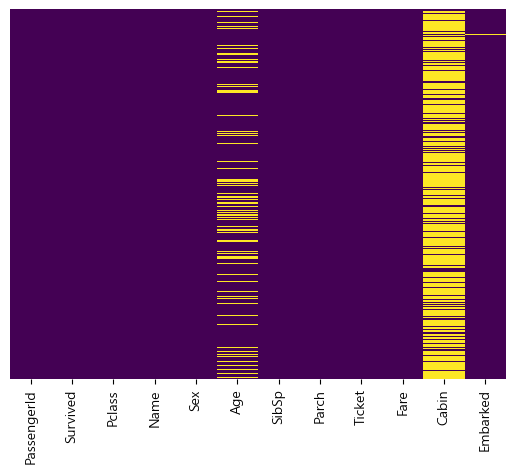

In [49]:
import seaborn as sns
#insert here
""" 
@param1 - 데이터셋에서 결측치가 있는지 확인해서 DataFrame반환합니다.
결측치가 있으면 True , 없으면 False
yticklabels - False이면 레이블을 표시하지 않습니다.
cbar - False이므로 색상막대는 표시하지 않습니다.
hitmap은 숫자 데이터를 색상으로 포시하는 그래프이다.
"""
sns.heatmap(df_train.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.show()